In [22]:
import pandas as pd
import numpy as np
import pydot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import export_graphviz

features = pd.read_csv('data.csv')
print(features.head(5))
print(features.describe())

   year  month  day  week  temp_2  temp_1  average  actual  forecast_noaa  \
0  2016      1    1   Fri      45      45     45.6      45             43   
1  2016      1    2   Sat      44      45     45.7      44             41   
2  2016      1    3   Sun      45      44     45.8      41             43   
3  2016      1    4   Mon      44      41     45.9      40             44   
4  2016      1    5  Tues      41      40     46.0      44             46   

   forecast_acc  forecast_under  friend  
0            50              44      29  
1            50              44      61  
2            46              47      56  
3            48              46      53  
4            46              46      41  
         year       month         day      temp_2      temp_1     average  \
count   348.0  348.000000  348.000000  348.000000  348.000000  348.000000   
mean   2016.0    6.477011   15.514368   62.652299   62.701149   59.760632   
std       0.0    3.498380    8.772982   12.165398   12

In [16]:
features = pd.get_dummies(features)
labels = np.array(features['actual'])
features = features.drop('actual', axis = 1)
feature_list = list(features.columns)
features = np.array(features)

In [17]:
train_X, test_X, train_y, test_y = train_test_split(features, labels, test_size = 0.25, random_state = 42)
rf = RandomForestRegressor(n_estimators = 1000, random_state = 42)
rf.fit(train_X, train_y)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [18]:
predictions = rf.predict(test_X)
errors = abs(predictions - test_y)
print('Mean Absolute Error:', round(np.mean(errors), 2), 'degrees.') #

mape = 100 * (errors / test_y)
accuracy = 100 - np.mean(mape)
print('Accuracy:', round(accuracy, 2), '%.') #

Mean Absolute Error: 3.87 degrees.
Accuracy: 93.93 %.


In [21]:
rf_small = RandomForestRegressor(n_estimators=10, max_depth = 3)
rf_small.fit(train_X, train_y)
tree_small = rf_small.estimators_[5]
export_graphviz(tree_small, out_file = 'small_tree.dot', feature_names = feature_list, rounded = True, precision = 1)
(graph, ) = pydot.graph_from_dot_file('small_tree.dot')
graph.write_png('small_tree.png')

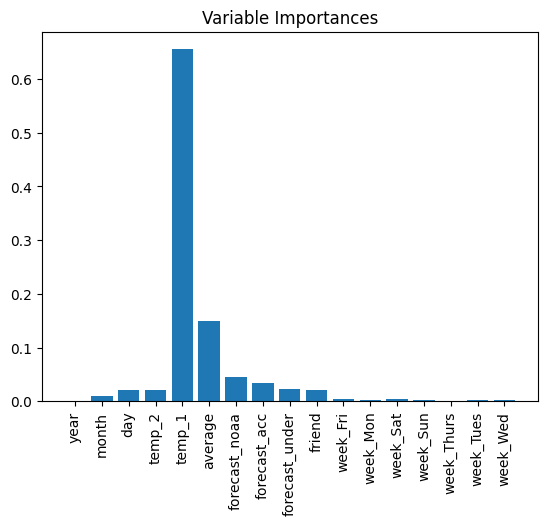

MAE (2 variables): 3.92


In [23]:
importances = list(rf.feature_importances_)
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), feature_list, rotation='vertical')
plt.title('Variable Importances')
plt.show()

rf_most_important = RandomForestRegressor(n_estimators=1000, random_state=42)
important_indices = [feature_list.index('temp_1'), feature_list.index('average')]
train_important = train_X[:, important_indices]
test_important = test_X[:, important_indices]

rf_most_important.fit(train_important, train_y)
predictions = rf_most_important.predict(test_important)
errors = abs(predictions - test_y)
print('MAE (2 variables):', round(np.mean(errors), 2)) #